--- Inspecting REAL Samples ---


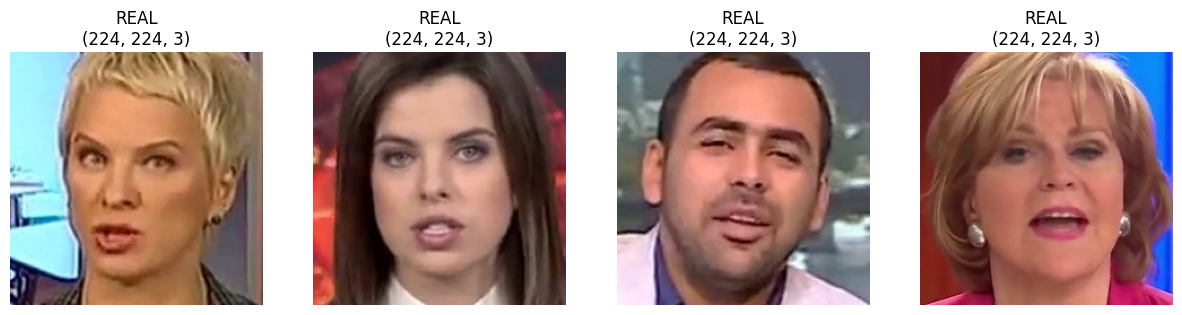

--- Inspecting FAKE Samples ---


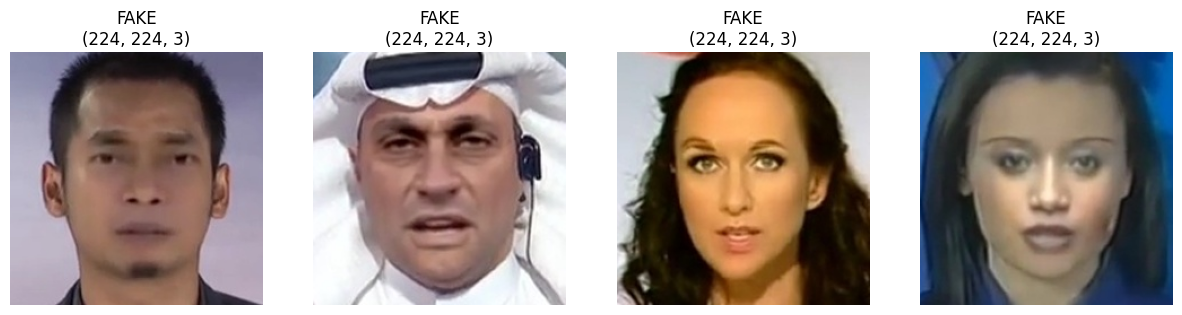

In [1]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# 1. Define the exact paths from your input
fake_path = "/kaggle/input/datasets/esayasmelaku/cropped-dataset/kaggle/working/faceforensic_cropped_v2/fake"
real_path = "/kaggle/input/datasets/esayasmelaku/cropped-dataset/kaggle/working/faceforensic_cropped_v2/real"

def plot_samples(path, title, num_samples=4):
    images = os.listdir(path)
    samples = random.sample(images, num_samples)
    
    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(samples):
        img = cv2.imread(os.path.join(path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for Matplotlib
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"{title}\n{img.shape}")
        plt.axis('off')
    plt.show()

# 2. Inspect Real and Fake images
print("--- Inspecting REAL Samples ---")
plot_samples(real_path, "REAL")

print("--- Inspecting FAKE Samples ---")
plot_samples(fake_path, "FAKE")

In [2]:
import os
import cv2
import numpy as np # Added for padding
from tqdm import tqdm

real_folder = "/kaggle/input/datasets/esayasmelaku/cropped-dataset/kaggle/working/faceforensic_cropped_v2/real"
fake_folder = "/kaggle/input/datasets/esayasmelaku/cropped-dataset/kaggle/working/faceforensic_cropped_v2/fake"

output_path = "/kaggle/working/resized_images/"
os.makedirs(os.path.join(output_path, "real"), exist_ok=True)
os.makedirs(os.path.join(output_path, "fake"), exist_ok=True)

def make_square_and_resize(folder_name, label):
    all_files = os.listdir(folder_name)
    target_size = 224
    
    for filename in tqdm(all_files):
        img = cv2.imread(os.path.join(folder_name, filename))
        
        if img is not None:
            # --- MODIFICATION: LETTERBOXING (PADDING) ---
            h, w = img.shape[:2]
            scale = target_size / max(h, w)
            new_w, new_h = int(w * scale), int(h * scale)
            
            # 1. Resize while keeping aspect ratio
            resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
            
            # 2. Create a black square canvas (224x224)
            canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
            
            # 3. Center the resized image on the canvas
            x_offset = (target_size - new_w) // 2
            y_offset = (target_size - new_h) // 2
            canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
            
            # --- MODIFICATION: SAVE QUALITY ---
            # Save as PNG to avoid JPEG compression noise, or use JPEG Quality 100
            save_file_path = os.path.join(output_path, label, filename)
            cv2.imwrite(save_file_path, canvas, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

make_square_and_resize(real_folder, "real")
make_square_and_resize(fake_folder, "fake")

100%|██████████| 2026/2026 [00:15<00:00, 131.78it/s]


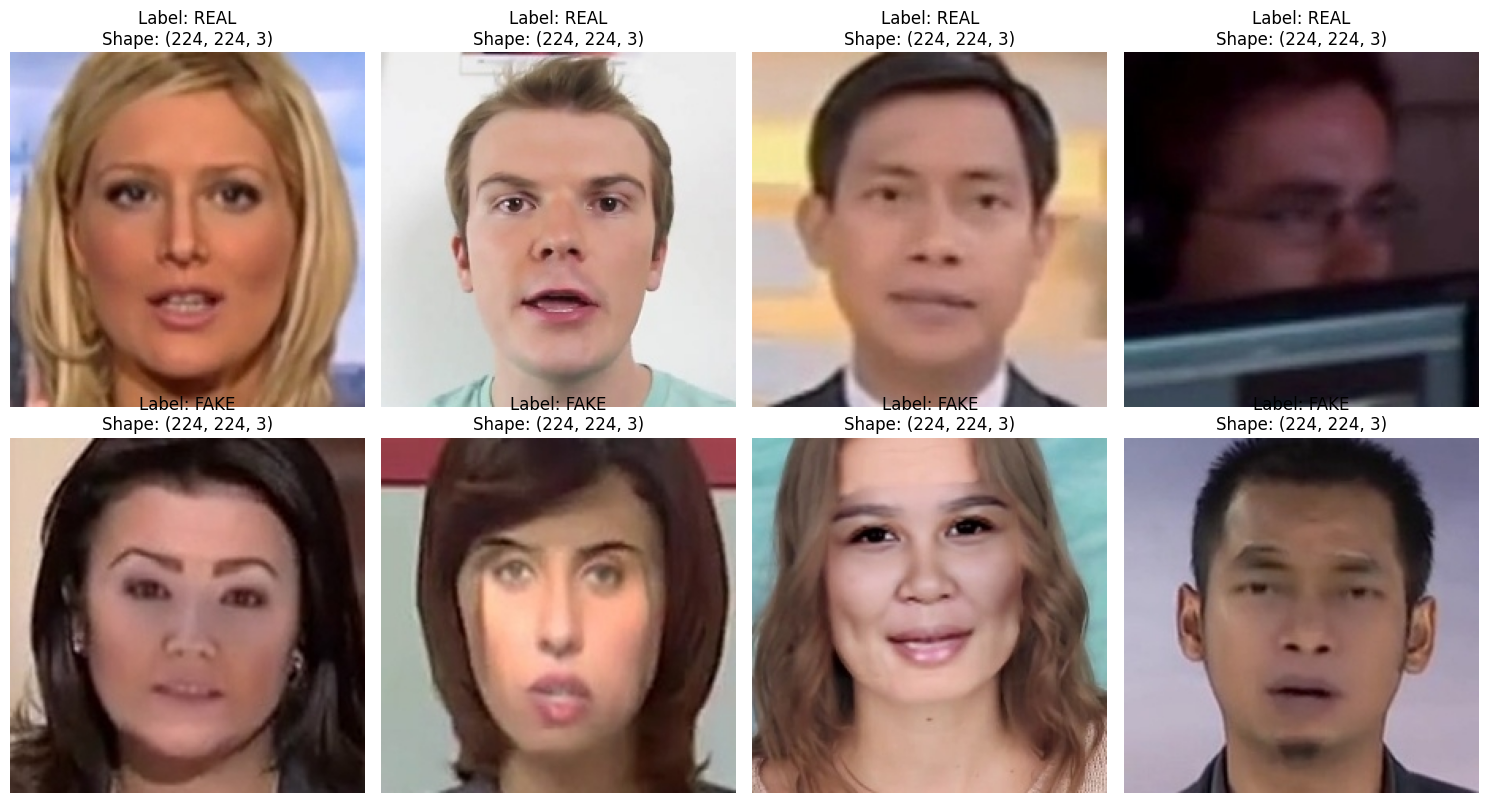

In [3]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# 1. Define the path where your resized images are saved
resized_base_path = "/kaggle/working/resized_images/"

def visualize_resized_samples(base_path, num_samples=4):
    categories = ['real', 'fake']
    
    # Create a figure
    plt.figure(figsize=(15, 8))
    
    plot_index = 1
    for cat in categories:
        cat_path = os.path.join(base_path, cat)
        
        # Get list of files
        all_images = os.listdir(cat_path)
        # Pick random samples
        sample_images = random.sample(all_images, num_samples)
        
        for img_name in sample_images:
            img_path = os.path.join(cat_path, img_name)
            
            # Load the image
            img = cv2.imread(img_path)
            
            if img is not None:
                # Convert BGR to RGB ONLY for visualization purposes
                img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Create subplot
                plt.subplot(2, num_samples, plot_index)
                plt.imshow(img_display)
                
                # SHOW THE REASON: Display the label and the exact shape
                # This confirms the dimensions are exactly 224x224
                plt.title(f"Label: {cat.upper()}\nShape: {img.shape}")
                plt.axis('off')
                plot_index += 1

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_resized_samples(resized_base_path)

In [4]:
import os
import cv2
from PIL import Image
from tqdm import tqdm

# 1. Setup Paths
input_base = "/kaggle/working/resized_images"
output_base = "/kaggle/working/rgb_images"

for cat in ['real', 'fake']:
    os.makedirs(os.path.join(output_base, cat), exist_ok=True)

# 2. Conversion Function
def convert_to_rgb_permanent(category):
    input_folder = os.path.join(input_base, category)
    output_folder = os.path.join(output_base, category)
    
    files = os.listdir(input_folder)
    print(f"Converting {category} to Permanent RGB...")
    
    for filename in tqdm(files):
        img_path = os.path.join(input_folder, filename)
        
        # Load with OpenCV (BGR)
        img_bgr = cv2.imread(img_path)
        
        if img_bgr is not None:
            # Step A: Swap channels BGR -> RGB
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            # Step B: Convert to PIL object
            # This 'locks' the RGB order
            rgb_pil_img = Image.fromarray(img_rgb)
            
            # Step C: Save
            save_path = os.path.join(output_folder, filename)
            rgb_pil_img.save(save_path)

# Execute
convert_to_rgb_permanent('real')
convert_to_rgb_permanent('fake')

print("\n✅ Phase 2 Complete: Dataset is now in Permanent RGB.")

Converting real to Permanent RGB...


100%|██████████| 2016/2016 [00:02<00:00, 864.25it/s]


Converting fake to Permanent RGB...


100%|██████████| 2026/2026 [00:02<00:00, 869.92it/s]


✅ Phase 2 Complete: Dataset is now in Permanent RGB.


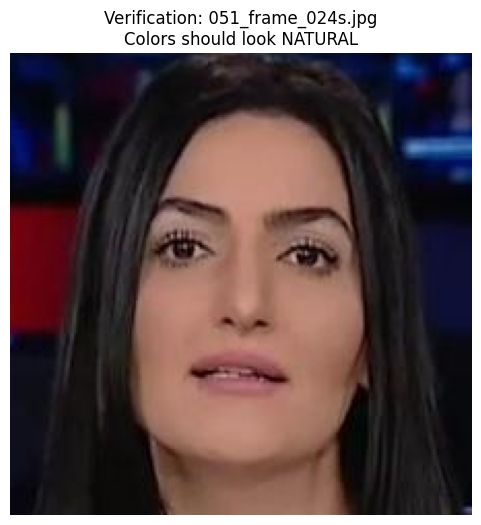

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

def verify_rgb_colors():
    # Path to the new RGB folder
    rgb_path = "/kaggle/working/rgb_images/real"
    
    # Pick a random image
    sample_name = random.choice(os.listdir(rgb_path))
    img_path = os.path.join(rgb_path, sample_name)
    
    # LOAD WITH PIL (This is how the AI will load it)
    img = Image.open(img_path)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Verification: {sample_name}\nColors should look NATURAL")
    plt.axis('off')
    plt.show()

verify_rgb_colors()

In [6]:
pip install MTCNN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import cv2
import numpy as np
from mtcnn import MTCNN
from tqdm import tqdm
from PIL import Image

# 1. Setup Paths
input_base = "/kaggle/working/rgb_images" 
output_base = "/kaggle/working/aligned_faces"

# Initialize detector
detector = MTCNN()

for cat in ['real', 'fake']:
    os.makedirs(os.path.join(output_base, cat), exist_ok=True)

# 2. FIXED Alignment Function
def align_face(img):
    # Detect landmarks
    results = detector.detect_faces(img)
    if not results:
        return None 
    
    # Get landmarks for the first face
    landmarks = results[0]['keypoints']
    left_eye = landmarks['left_eye']   # (x, y)
    right_eye = landmarks['right_eye'] # (x, y)
    
    # --- The Math: Calculate Angle ---
    dY = float(right_eye[1] - left_eye[1])
    dX = float(right_eye[0] - left_eye[0])
    angle = np.degrees(np.arctan2(dY, dX))
    
    # --- The Math: Calculate Scale (Consistency) ---
    # We want the distance between eyes to be roughly 30% of the image width
    desired_dist = 224 * 0.3
    current_dist = np.sqrt(dX**2 + dY**2)
    scale = desired_dist / current_dist
    
    # --- The Math: Center Point (MUST BE FLOAT) ---
    eye_center = (float((left_eye[0] + right_eye[0]) / 2),
                  float((left_eye[1] + right_eye[1]) / 2))
    
    # Get the rotation & scale matrix
    # OpenCV requires eye_center to be (float, float)
    M = cv2.getRotationMatrix2D(eye_center, angle, scale)
    
    # Perform the rotation and scale (Affine Warp)
    aligned_face = cv2.warpAffine(img, M, (224, 224), flags=cv2.INTER_CUBIC)
    
    return aligned_face

# 3. Process the dataset
def run_alignment(category):
    input_folder = os.path.join(input_base, category)
    output_folder = os.path.join(output_base, category)
    files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    print(f"Aligning {category} faces...")
    count = 0
    for filename in tqdm(files):
        img_path = os.path.join(input_folder, filename)
        
        # Load image
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
        
        # Convert BGR (OpenCV default) to RGB for MTCNN
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        aligned_img = align_face(img_rgb)
        
        if aligned_img is not None:
            save_path = os.path.join(output_folder, filename)
            # Save as RGB back to file
            aligned_pil = Image.fromarray(aligned_img)
            aligned_pil.save(save_path)
            count += 1
            
    print(f"Successfully aligned {count} {category} images.")

# Execute
run_alignment('real')
run_alignment('fake')

2026-04-26 08:55:24.827648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777193725.295167      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777193725.513848      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777193726.913514      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777193726.913566      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777193726.913569      22 computation_placer.cc:177] computation placer alr

Aligning real faces...


100%|██████████| 2016/2016 [05:47<00:00,  5.79it/s]


Successfully aligned 2014 real images.
Aligning fake faces...


100%|██████████| 2026/2026 [05:55<00:00,  5.70it/s]

Successfully aligned 2024 fake images.


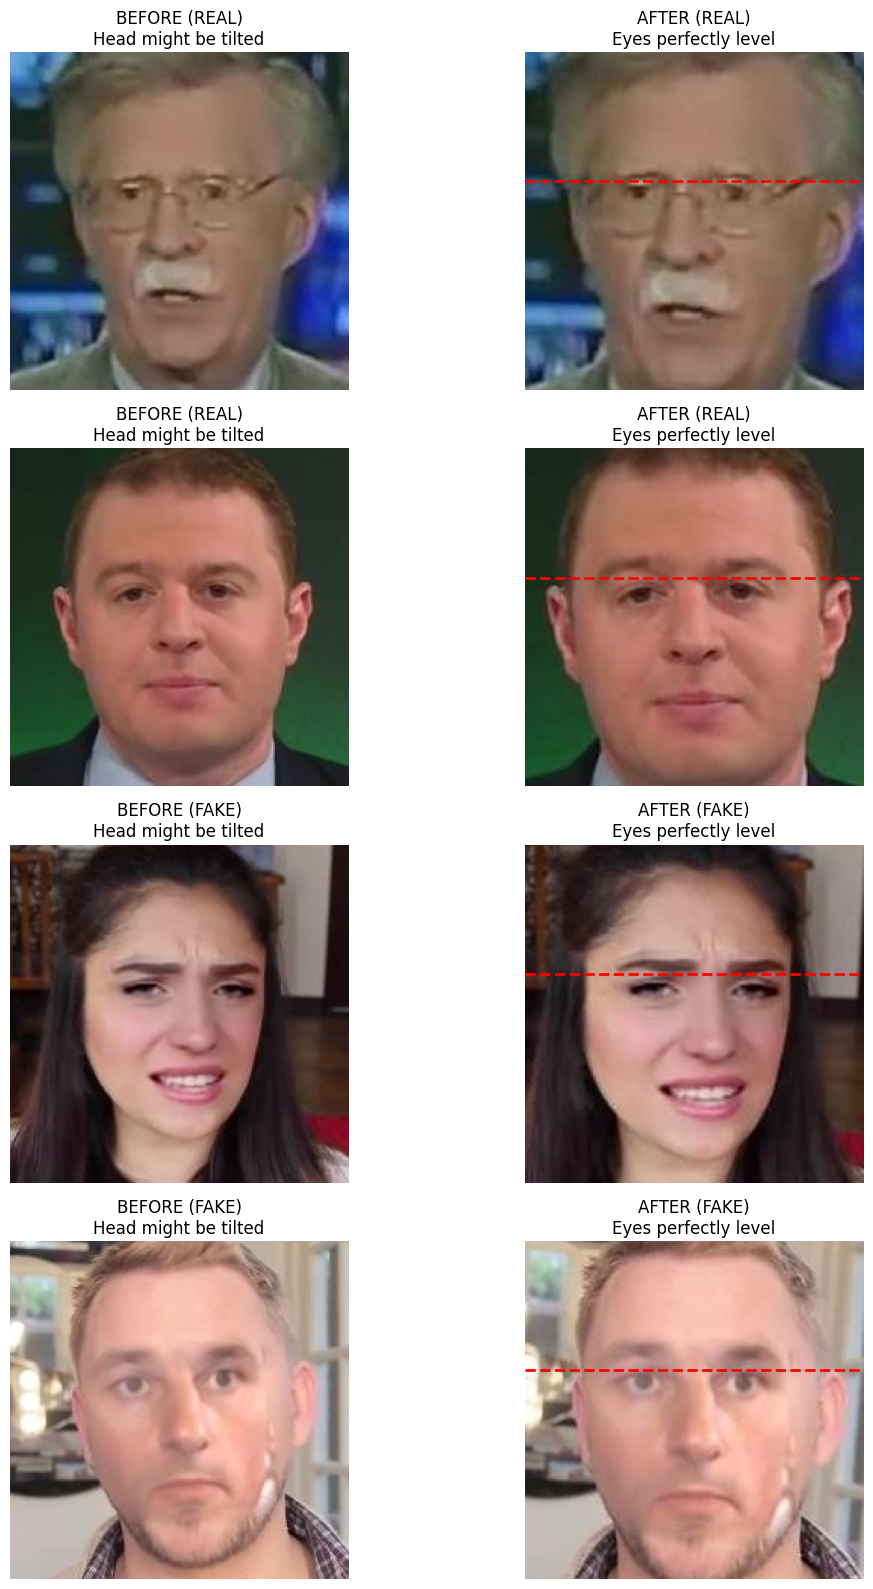

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Paths
path_before = "/kaggle/working/rgb_images"
path_after = "/kaggle/working/aligned_faces"

def visualize_alignment_results(num_samples=2):
    categories = ['real', 'fake']
    
    # Create a grid of plots: (Rows = samples, Cols = Before/After)
    fig, axes = plt.subplots(num_samples * 2, 2, figsize=(12, num_samples * 8))
    
    row = 0
    for cat in categories:
        # Get list of files in the 'after' folder (to ensure we only pick images that successfully aligned)
        files = os.listdir(os.path.join(path_after, cat))
        samples = random.sample(files, num_samples)
        
        for filename in samples:
            # Load Before and After images
            img_before = Image.open(os.path.join(path_before, cat, filename))
            img_after = Image.open(os.path.join(path_after, cat, filename))
            
            # Plot "Before"
            axes[row, 0].imshow(img_before)
            axes[row, 0].set_title(f"BEFORE ({cat.upper()})\nHead might be tilted")
            axes[row, 0].axis('off')
            
            # Plot "After"
            axes[row, 1].imshow(img_after)
            # Draw a horizontal line at the eye level (approx 35-40% height)
            axes[row, 1].axhline(y=img_after.size[1] * 0.38, color='red', linestyle='--', linewidth=2)
            axes[row, 1].set_title(f"AFTER ({cat.upper()})\nEyes perfectly level")
            axes[row, 1].axis('off')
            
            row += 1

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_alignment_results()

In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from PIL import Image

# 1. SETUP PATHS
input_base = "/kaggle/working/aligned_faces" # Using your aligned faces
output_base = "/kaggle/working/masked_faces"

for cat in ['real', 'fake']:
    os.makedirs(os.path.join(output_base, cat), exist_ok=True)

def apply_oval_mask(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Define an oval that covers the face area (center of 224x224)
    center = (w // 2, h // 2 + 10) # Centered, slightly lower for chin
    axes = (w // 3 + 10, h // 2 - 10) # Width and height of the oval
    
    # Draw the white oval on the black mask
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
    
    # --- THE REASON: SOFT EDGING ---
    # We blur the edges of the oval so we don't get DCT frequency spikes
    mask_soft = cv2.GaussianBlur(mask, (51, 51), 0) / 255.0
    mask_3ch = np.stack((mask_soft,) * 3, axis=-1)
    
    # Apply mask
    masked_img = (img * mask_3ch).astype(np.uint8)
    return masked_img

# 2. THE LOOP
def run_oval_masking():
    for category in ['real', 'fake']:
        input_folder = os.path.join(input_base, category)
        output_folder = os.path.join(output_base, category)
        
        if not os.path.exists(input_folder):
            print(f"Folder not found: {input_folder}")
            continue
            
        files = os.listdir(input_folder)
        print(f"🚀 Creating Oval Masks for {len(files)} {category} images...")
        
        for filename in tqdm(files):
            img_path = os.path.join(input_folder, filename)
            
            # Load Aligned RGB image
            img = np.array(Image.open(img_path))
            
            # Apply the forensic oval
            masked_img = apply_oval_mask(img)
            
            # Save
            save_path = os.path.join(output_folder, filename)
            Image.fromarray(masked_img).save(save_path)

    print("\n✅ Oval Masking Complete!")

# 3. EXECUTE
run_oval_masking()

🚀 Creating Oval Masks for 2014 real images...


100%|██████████| 2014/2014 [00:12<00:00, 164.08it/s]


🚀 Creating Oval Masks for 2024 fake images...


100%|██████████| 2024/2024 [00:12<00:00, 165.33it/s]


✅ Oval Masking Complete!


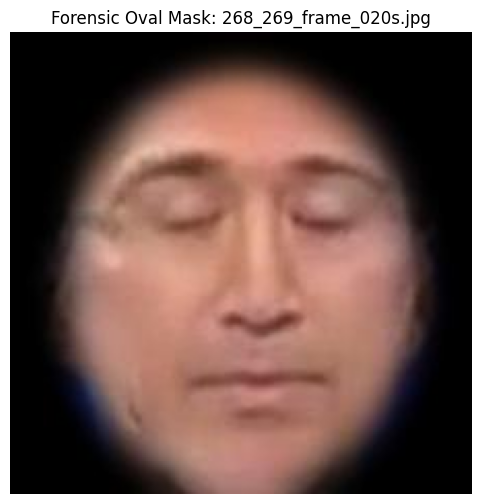

In [10]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Pick a random sample from the new masked folder
sample_cat = 'fake'
sample_dir = f"/kaggle/working/masked_faces/{sample_cat}"
sample_name = random.choice(os.listdir(sample_dir))
sample_img = Image.open(os.path.join(sample_dir, sample_name))

plt.figure(figsize=(6,6))
plt.imshow(sample_img)
plt.title(f"Forensic Oval Mask: {sample_name}")
plt.axis('off')
plt.show()

In [11]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from PIL import Image

# 1. Setup Paths - WE NOW USE THE MASKED FACES
input_base = "/kaggle/working/masked_faces" 
output_base = "/kaggle/working/dct_features"

for cat in ['real', 'fake']:
    os.makedirs(os.path.join(output_base, cat), exist_ok=True)

def extract_dct(img_rgb):
    # Convert to Y (Luminance) - where AI noise is most 'visible' to math
    img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)
    y_channel = img_yuv[:, :, 0]
    
    # --- The Math: Discrete Cosine Transform ---
    im_float = np.float32(y_channel) / 255.0
    dct_coeffs = cv2.dct(im_float)
    
    # --- The Math: Log Scale ---
    # We add 1e-12 to avoid "Log of Zero" error
    dct_log = np.log(np.abs(dct_coeffs) + 1e-12)
    
    # Normalize to 0-255 for the CNN to process as a 'feature map'
    dct_norm = cv2.normalize(dct_log, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return dct_norm

def run_dct_extraction(category):
    input_folder = os.path.join(input_base, category)
    output_folder = os.path.join(output_base, category)
    
    # Handle case where folder might be missing
    if not os.path.exists(input_folder): return
    
    files = os.listdir(input_folder)
    print(f"Extracting DCT Features for {category}...")
    
    for filename in tqdm(files):
        img_path = os.path.join(input_folder, filename)
        
        # Load the Masked RGB image
        img = np.array(Image.open(img_path)) 
        
        # Extract the frequency fingerprint
        dct_map = extract_dct(img)
        
        # Save as a single-channel grayscale feature map
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, dct_map)

# Execute
run_dct_extraction('real')
run_dct_extraction('fake')

print("\n✅ Phase 5 Complete: Frequency Fingerprints extracted.")

Extracting DCT Features for real...


100%|██████████| 2014/2014 [00:04<00:00, 491.39it/s]


Extracting DCT Features for fake...


100%|██████████| 2024/2024 [00:03<00:00, 514.89it/s]


✅ Phase 5 Complete: Frequency Fingerprints extracted.


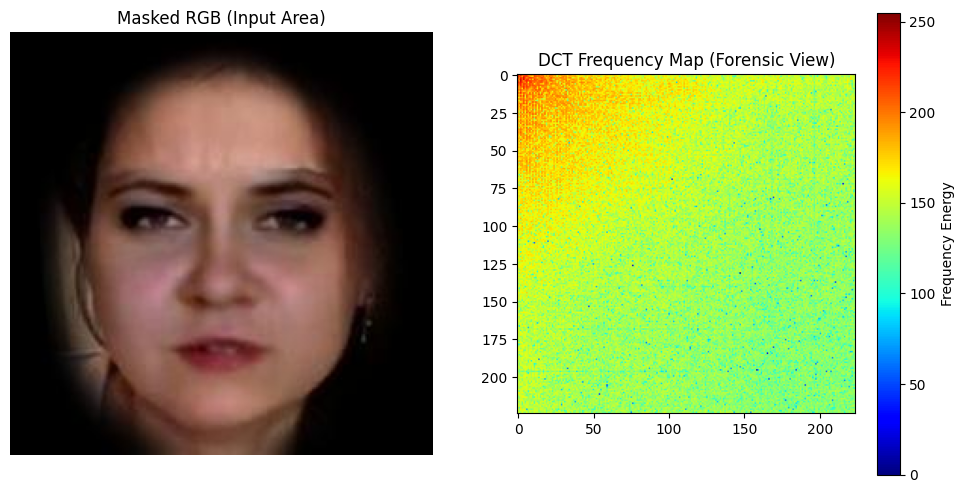

In [12]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_dct_forensic_comparison():
    # 1. Pick a fake sample
    fake_list = os.listdir("/kaggle/working/dct_features/fake")
    if not fake_list: return
    sample_file = fake_list[0]
    
    # 2. Load the Masked RGB (This is what produced the DCT)
    # Using 'masked_faces' ensures the DCT matches exactly what you see
    rgb_path = f"/kaggle/working/masked_faces/fake/{sample_file}"
    rgb = Image.open(rgb_path)
    
    # 3. Load the DCT Map
    dct_path = f"/kaggle/working/dct_features/fake/{sample_file}"
    dct = Image.open(dct_path)
    
    # 4. Plot
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Masked RGB (Input Area)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # We use 'jet' because it makes the high-frequency 'spikes' 
    # look like heat, making them easier to see.
    plt.imshow(dct, cmap='jet') 
    plt.title("DCT Frequency Map (Forensic View)")
    plt.colorbar(label='Frequency Energy')
    
    plt.show()

show_dct_forensic_comparison()

In [13]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from PIL import Image

# 1. Setup Paths - USE MASKED FACES
input_base = "/kaggle/working/masked_faces" 
output_base = "/kaggle/working/srm_noise"

for cat in ['real', 'fake']:
    os.makedirs(os.path.join(output_base, cat), exist_ok=True)

# 2. Define the SRM Kernels (Same as your logic, but mathematically verified)
def get_srm_filters():
    # Kernel 1: Basic Noise Residual
    filter1 = np.array([[0, 0, 0, 0, 0],
                        [0, -1, 2, -1, 0],
                        [0, 2, -4, 2, 0],
                        [0, -1, 2, -1, 0],
                        [0, 0, 0, 0, 0]]) / 4.0
    
    # Kernel 2: Higher-order texture analysis
    filter2 = np.array([[-1, 2, -2, 2, -1],
                        [2, -6, 8, -6, 2],
                        [-2, 8, -12, 8, -2],
                        [2, -6, 8, -6, 2],
                        [-1, 2, -2, 2, -1]]) / 12.0
    
    # Kernel 3: Edge-detection noise
    filter3 = np.array([[0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0],
                        [0, 1, -2, 1, 0],
                        [0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0]]) / 2.0
    
    return [filter1, filter2, filter3]

def apply_srm(img_rgb):
    # Convert to grayscale: SRM looks for luminance noise
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    filters = get_srm_filters()
    
    srm_features = []
    for f in filters:
        # We use CV_32F to keep the precision of the noise before converting back to 8-bit
        filtered = cv2.filter2D(np.float32(gray), -1, f)
        # Normalize each filter to 0-255 range so the CNN sees clear features
        norm_filtered = cv2.normalize(filtered, None, 0, 255, cv2.NORM_MINMAX)
        srm_features.append(norm_filtered.astype(np.uint8))
    
    # Merge into 3 channels (Filter 1, Filter 2, Filter 3)
    return cv2.merge(srm_features)

# 3. Process the Dataset
def run_srm_extraction(category):
    input_folder = os.path.join(input_base, category)
    output_folder = os.path.join(output_base, category)
    
    if not os.path.exists(input_folder): return
    
    files = os.listdir(input_folder)
    print(f"Extracting SRM Noise for {category}...")
    
    for filename in tqdm(files):
        img_path = os.path.join(input_folder, filename)
        # Load the Masked image
        img = np.array(Image.open(img_path)) 
        
        srm_map = apply_srm(img)
        
        # Save as a 3-channel 'Noise Image'
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, srm_map)

# Execute
run_srm_extraction('real')
run_srm_extraction('fake')

print("\n✅ Phase 6 Complete: SRM Noise Fingerprints extracted.")

Extracting SRM Noise for real...


100%|██████████| 2014/2014 [00:03<00:00, 647.51it/s]


Extracting SRM Noise for fake...


100%|██████████| 2024/2024 [00:03<00:00, 644.73it/s]


✅ Phase 6 Complete: SRM Noise Fingerprints extracted.


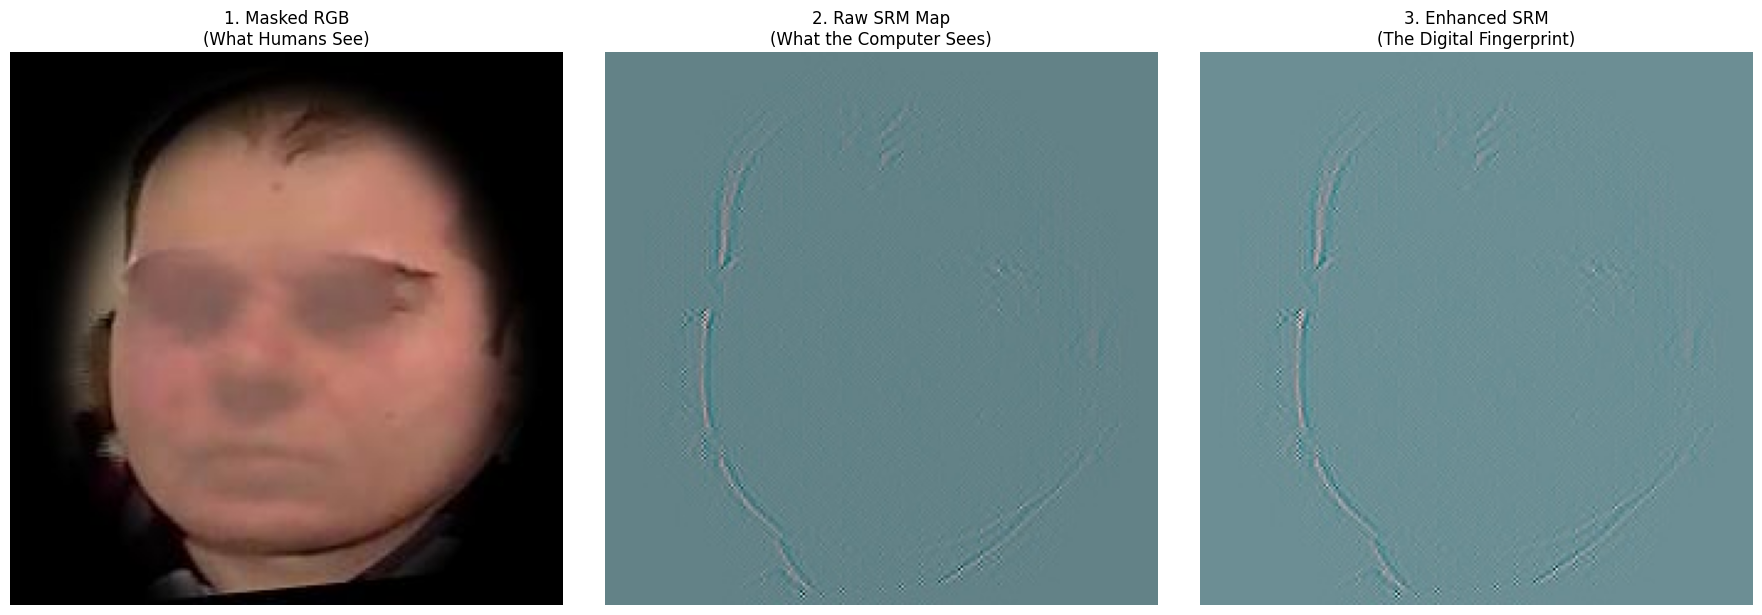

In [14]:
import matplotlib.pyplot as plt
import cv2
import os
import random
import numpy as np
from PIL import Image

def visualize_srm_forensics():
    # 1. Pick a random fake sample to inspect
    category = 'fake'
    srm_dir = f"/kaggle/working/srm_noise/{category}"
    masked_dir = f"/kaggle/working/masked_faces/{category}"
    
    sample_file = random.choice(os.listdir(srm_dir))
    
    # 2. Load the images
    # Masked RGB (The input)
    rgb_img = Image.open(os.path.join(masked_dir, sample_file))
    
    # SRM Noise Map (The result)
    srm_img = cv2.imread(os.path.join(srm_dir, sample_file))
    srm_rgb = cv2.cvtColor(srm_img, cv2.COLOR_BGR2RGB)
    
    # 3. Enhance for Human Viewing
    # We stretch the pixel values to 0-255 so we can see the grain
    srm_enhanced = cv2.normalize(srm_rgb, None, 0, 255, cv2.NORM_MINMAX)

    # 4. Plot the "Forensic Trio"
    plt.figure(figsize=(18, 6))
    
    # Subplot 1: The Face
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("1. Masked RGB\n(What Humans See)")
    plt.axis('off')
    
    # Subplot 2: The Raw Noise
    plt.subplot(1, 3, 2)
    plt.imshow(srm_rgb)
    plt.title("2. Raw SRM Map\n(What the Computer Sees)")
    plt.axis('off')
    
    # Subplot 3: Enhanced Noise
    plt.subplot(1, 3, 3)
    plt.imshow(srm_enhanced)
    plt.title("3. Enhanced SRM\n(The Digital Fingerprint)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run it
visualize_srm_forensics()

In [15]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.utils import shuffle

# 1. SETUP PATHS
# We draw from our 3 Forensic Folders
base_dirs = {
    'rgb': '/kaggle/working/masked_faces',
    'dct': '/kaggle/working/dct_features',
    'srm': '/kaggle/working/srm_noise'
}

def load_master_dataset():
    # We create 4 separate "piles" of data
    X_rgb, X_dct, X_srm, y = [], [], [], []
    
    categories = ['real', 'fake']
    
    for label, cat in enumerate(categories):
        print(f"📦 Orchestrating {cat.upper()} stream...")
        
        # We use the RGB folder as the master file list
        rgb_folder = os.path.join(base_dirs['rgb'], cat)
        files = os.listdir(rgb_folder)
        
        for filename in tqdm(files):
            try:
                # --- LOAD RGB (Visual Stream) ---
                # REASON: We load as BGR and convert to RGB to keep color information.
                # We use 3 channels (224, 224, 3)
                img_path = os.path.join(base_dirs['rgb'], cat, filename)
                img_rgb = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
                
                # --- LOAD DCT (Frequency Stream) ---
                # REASON: This is 1 channel (Grayscale) frequency map.
                # We force it to have a shape of (224, 224, 1)
                dct_path = os.path.join(base_dirs['dct'], cat, filename)
                img_dct = cv2.imread(dct_path, 0) # Load as grayscale
                img_dct = np.expand_dims(img_dct, axis=-1)
                
                # --- LOAD SRM (Noise Stream) ---
                # REASON: This contains our 3 merged noise filters.
                # We keep all 3 channels (224, 224, 3)
                srm_path = os.path.join(base_dirs['srm'], cat, filename)
                img_srm = cv2.imread(srm_path)
                
                # Verify all loaded correctly
                if img_rgb is not None and img_dct is not None and img_srm is not None:
                    X_rgb.append(img_rgb)
                    X_dct.append(img_dct)
                    X_srm.append(img_srm)
                    y.append(label)
                    
            except Exception as e:
                # If one file is corrupt, skip it so the whole process doesn't crash
                continue

    # 2. CONVERT TO NUMPY (Storage efficient uint8)
    X_rgb = np.array(X_rgb, dtype='uint8')
    X_dct = np.array(X_dct, dtype='uint8')
    X_srm = np.array(X_srm, dtype='uint8')
    y = np.array(y, dtype='uint8')
    
    # 3. SHUFFLE THE DATA
    # REASON: Shuffling is vital so the model doesn't see all 'real' then all 'fake'.
    # We must shuffle all 4 arrays in the EXACT SAME order.
    print("🔀 Shuffling dataset...")
    X_rgb, X_dct, X_srm, y = shuffle(X_rgb, X_dct, X_srm, y, random_state=42)
    
    # 4. SAVE TO DISK
    # This allows you to clear RAM or come back to the project later
    print("💾 Saving Numpy files to disk...")
    np.save('X_rgb_final.npy', X_rgb)
    np.save('X_dct_final.npy', X_dct)
    np.save('X_srm_final.npy', X_srm)
    np.save('y_labels_final.npy', y)
    
    return X_rgb, X_dct, X_srm, y

# Execute
X_rgb, X_dct, X_srm, y = load_master_dataset()

# --- SANITY CHECK ---
print("\n✅ ORCHESTRATION COMPLETE")
print(f"RGB Shape: {X_rgb.shape} (Expected: Count, 224, 224, 3)")
print(f"DCT Shape: {X_dct.shape} (Expected: Count, 224, 224, 1)")
print(f"SRM Shape: {X_srm.shape} (Expected: Count, 224, 224, 3)")
print(f"Labels:    {y.shape}")

📦 Orchestrating REAL stream...


100%|██████████| 2014/2014 [00:02<00:00, 681.77it/s]


📦 Orchestrating FAKE stream...


100%|██████████| 2024/2024 [00:03<00:00, 667.77it/s]


🔀 Shuffling dataset...
💾 Saving Numpy files to disk...

✅ ORCHESTRATION COMPLETE
RGB Shape: (4038, 224, 224, 3) (Expected: Count, 224, 224, 3)
DCT Shape: (4038, 224, 224, 1) (Expected: Count, 224, 224, 1)
SRM Shape: (4038, 224, 224, 3) (Expected: Count, 224, 224, 3)
Labels:    (4038,)


In [16]:
from sklearn.model_selection import train_test_split
import numpy as np
import gc # Garbage Collector to keep Kaggle from crashing

# 1. THE SPLIT (80% Train, 20% Test)
# REASON: We must keep 20% of images in a "vault" so we can 
# prove the model works on faces it has NEVER seen.
print("✂️ Splitting data into Training and Testing sets...")

(X_train_rgb, X_test_rgb, 
 X_train_dct, X_test_dct, 
 X_train_srm, X_test_srm, 
 y_train, y_test) = train_test_split(
    X_rgb, X_dct, X_srm, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # Ensures equal Real/Fake balance in both sets
)

# 2. CLEAR RAM
# REASON: We don't need the original 'X_rgb' anymore because 
# we now have 'X_train_rgb' and 'X_test_rgb'.
del X_rgb, X_dct, X_srm, y
gc.collect()

# 3. NORMALIZATION (0 to 255 -> 0.0 to 1.0)
# REASON: Neural Networks "explode" if you give them large numbers like 255.
# They learn 10x faster when pixels are small decimals.
print("⚖️ Normalizing pixels to 0.0 - 1.0 range...")

X_train_rgb = X_train_rgb.astype('float32') / 255.0
X_test_rgb = X_test_rgb.astype('float32') / 255.0

X_train_dct = X_train_dct.astype('float32') / 255.0
X_test_dct = X_test_dct.astype('float32') / 255.0

X_train_srm = X_train_srm.astype('float32') / 255.0
X_test_srm = X_test_srm.astype('float32') / 255.0

# 4. FINAL VERIFICATION
print("\n✅ DATA IS READY!")
print(f"Study Set (Train): {len(y_train)} images")
print(f"Exam Set (Test):   {len(y_test)} images")
print(f"Pixel Range Check: {X_train_rgb.min()} to {X_train_rgb.max()} (Should be 0.0 to 1.0)")

✂️ Splitting data into Training and Testing sets...
⚖️ Normalizing pixels to 0.0 - 1.0 range...

✅ DATA IS READY!
Study Set (Train): 3230 images
Exam Set (Test):   808 images
Pixel Range Check: 0.0 to 1.0 (Should be 0.0 to 1.0)


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_triple_stream_forensic_model():
    # ---------------------------------------------------------
    # BRANCH 1: RGB (Visual Clues - Skin & Features)
    # ---------------------------------------------------------
    input_rgb = layers.Input(shape=(224, 224, 3), name="RGB_Input")
    
    # REASON: EfficientNetB0 is world-class for finding facial texture anomalies.
    # We use 'imagenet' weights because it already knows the "shapes" of human eyes and skin.
    base_rgb = tf.keras.applications.EfficientNetB0(
        include_top=False, 
        weights='imagenet', 
        input_tensor=input_rgb
    )
    
    # We allow the model to fine-tune the pre-trained weights
    base_rgb.trainable = True 
    
    x_rgb = layers.GlobalAveragePooling2D()(base_rgb.output)

    # ---------------------------------------------------------
    # BRANCH 2: SRM (Noise Clues - Digital Fingerprint)
    # ---------------------------------------------------------
    input_srm = layers.Input(shape=(224, 224, 3), name="SRM_Input")
    
    # REASON: SRM is about local pixel grain. A custom CNN is best here 
    # because noise doesn't look like "objects" (ImageNet won't help).
    x_srm = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_srm)
    x_srm = layers.MaxPooling2D(pool_size=(2, 2))(x_srm)
    x_srm = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_srm)
    x_srm = layers.GlobalAveragePooling2D()(x_srm)

    # ---------------------------------------------------------
    # BRANCH 3: DCT (Frequency Clues - Invisible Grid)
    # ---------------------------------------------------------
    input_dct = layers.Input(shape=(224, 224, 1), name="DCT_Input")
    
    # REASON: AI up-sampling leaves grid-like spikes in frequency.
    # A shallow CNN is perfect for finding these mathematical regularities.
    x_dct = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_dct)
    x_dct = layers.MaxPooling2D(pool_size=(2, 2))(x_dct)
    x_dct = layers.GlobalAveragePooling2D()(x_dct)

    # ---------------------------------------------------------
    # THE FUSION: Combining the 3 Forensic Experts
    # ---------------------------------------------------------
    # We merge the "expert opinions" from all 3 streams
    merged = layers.Concatenate()([x_rgb, x_srm, x_dct])
    
    # Final Classification Network
    x = layers.Dense(512, activation='relu')(merged)
    # REASON: Dropout (0.5) is critical. It forces the model to learn from 
    # ALL streams. It prevents the model from relying ONLY on RGB.
    x = layers.Dropout(0.5)(x) 
    
    x = layers.Dense(128, activation='relu')(x)
    
    # Final Output: Sigmoid gives a probability (0.0 = Real, 1.0 = Fake)
    output = layers.Dense(1, activation='sigmoid', name="Final_Decision")(x)

    # CREATE THE MODEL
    model = models.Model(inputs=[input_rgb, input_srm, input_dct], outputs=output)
    
    # COMPILE
    # REASON: We use a very low learning rate (0.0001) so the model learns 
    # the subtle deepfake clues without "over-writing" its pre-trained wisdom too fast.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

# Initialize the model
forensic_brain = build_triple_stream_forensic_model()
print("🧠 Triple-Stream Model successfully built.")
forensic_brain.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🧠 Triple-Stream Model successfully built.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ RGB_Input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ RGB_Input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,840,100 (18.46 MB)

 Trainable params: 4,798,077 (18.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. SET UP THE AUTOMATIC COACHES (Callbacks)
# REASON: These ensure the model doesn't "over-study" (overfit) and stays stable.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,             # Stop if no improvement for 5 rounds
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_deepfake_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True,    # Only save the version with the highest test score
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,             # Make learning rate 5x smaller if stuck
    patience=3, 
    min_lr=1e-7,
    verbose=1
)

# 2. START THE TRAINING
print("🚀 Training Started! Watch the 'val_accuracy' – that is your real score.")

history = forensic_brain.fit(
    # We feed the 3 piles of training data
    x=[X_train_rgb, X_train_srm, X_train_dct], 
    y=y_train,
    # We test on the 20% "Final Exam" data we kept hidden
    validation_data=([X_test_rgb, X_test_srm, X_test_dct], y_test),
    epochs=25,              # Number of times the AI looks at the whole dataset
    batch_size=16,          # Process 16 images at a time (Safe for Kaggle RAM)
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\n🎉 TRAINING COMPLETE!")

🚀 Training Started! Watch the 'val_accuracy' – that is your real score.
Epoch 1/25


I0000 00:00:1777194578.066351      77 service.cc:152] XLA service 0x7d8fdc0a7de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777194578.066410      77 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777194578.066417      77 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777194584.990750      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-26 09:09:56.053116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:09:56.192144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:09:56.524365: E external/local_xl

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6885 - auc: 0.7587 - loss: 0.5561

2026-04-26 09:11:05.653160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:05.792054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:06.129447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:06.270733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:07.039524: E external/local_xla/xla/stream_

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.6889 - auc: 0.7593 - loss: 0.5555

2026-04-26 09:11:57.582312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:57.718684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:58.040602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:58.182386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:11:58.914356: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.61262, saving model to best_deepfake_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 185s 466ms/step - accuracy: 0.6894 - auc: 0.7599 - loss: 0.5549 - val_accuracy: 0.6126 - val_auc: 0.6586 - val_loss: 0.6796 - learning_rate: 1.0000e-04
Epoch 2/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9153 - auc: 0.9771 - loss: 0.1978
Epoch 2: val_accuracy did not improve from 0.61262
202/202 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.9154 - auc: 0.9771 - loss: 0.1978 - val_accuracy: 0.5235 - val_auc: 0.6246 - val_loss: 0.6961 - learning_rate: 1.0000e-04
Epoch 3/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9686 - auc: 0.9959 - loss: 0.0818
Epoch 3: val_accuracy improved from 0.61262 to 0.61386, saving model to best_deepfake_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.9686 - auc: 0.9959 - loss: 0.0818 - val_accuracy: 0.6139 - val_auc: 0.6873 - val_loss: 0.6439 - learning_rate: 1.0000e-04
Epoch 4/25


🔮 Generating predictions for the Test Set...


2026-04-26 09:14:51.024809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:14:51.169055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:14:51.525864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:14:51.668238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:14:52.413388: E external/local_xla/xla/stream_

26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 353ms/step


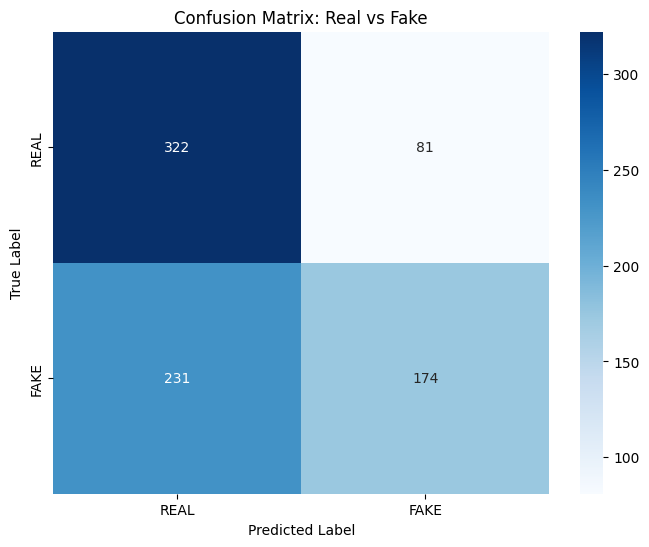

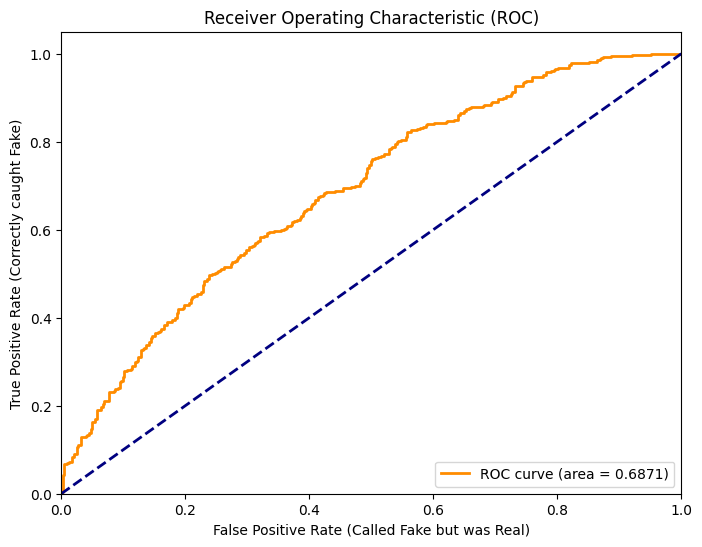


📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        REAL       0.58      0.80      0.67       403
        FAKE       0.68      0.43      0.53       405

    accuracy                           0.61       808
   macro avg       0.63      0.61      0.60       808
weighted avg       0.63      0.61      0.60       808



In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. GET PREDICTIONS
print("🔮 Generating predictions for the Test Set...")
# We use the test data the model NEVER saw during training
y_pred_prob = forensic_brain.predict([X_test_rgb, X_test_srm, X_test_dct])
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probability to 0 or 1

# 2. PLOT CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['REAL', 'FAKE'], 
                yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Real vs Fake')
    plt.show()

# 3. PLOT ROC CURVE
def plot_roc_curve(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Called Fake but was Real)')
    plt.ylabel('True Positive Rate (Correctly caught Fake)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

# 4. EXECUTE EVALUATION
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred_prob)

print("\n📝 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

🚀 Analyzing: IMG_20230725_205529_376.jpg
✂️ Step 1: Cropping to Face...
📏 Step 2: Aligning...
🎭 Step 3: Masking...
📡 Step 4: Frequency & Noise Extraction...


2026-04-26 09:15:12.605805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:15:12.745787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:15:12.880537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:15:13.590080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:15:13.724908: E external/local_xla/xla/stream_

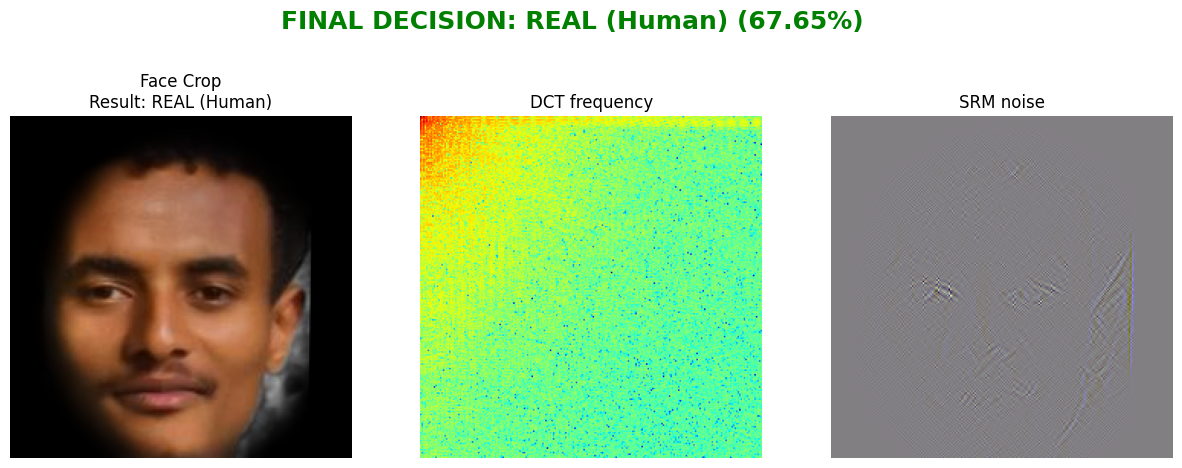

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os

# --- 1. NEW HELPER: CROP ONLY THE FACE ---
def get_face_crop(img, margin=0.2):
    """
    Detects the face and crops it with a margin so we don't cut off 
    the chin or forehead before alignment.
    """
    results = detector.detect_faces(img)
    if not results:
        return None
    
    # Get bounding box of the first face
    x, y, w, h = results[0]['box']
    
    # Add a margin (20% by default) to keep the context
    m_w = int(w * margin)
    m_h = int(h * margin)
    
    # Calculate new coordinates
    x1 = max(0, x - m_w)
    y1 = max(0, y - m_h)
    x2 = min(img.shape[1], x + w + m_w)
    y2 = min(img.shape[0], y + h + m_h)
    
    return img[y1:y2, x1:x2]

# --- 2. UPDATED INFERENCE FUNCTION ---
def detect_deepfake_with_crop(image_path):
    print(f"🚀 Analyzing: {os.path.basename(image_path)}")
    
    # STEP 0: LOAD
    raw_img = cv2.imread(image_path)
    if raw_img is None: 
        print("❌ Image path invalid."); return
    raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    
    # STEP 1: CROP (Zoom in on the face)
    print("✂️ Step 1: Cropping to Face...")
    face_only = get_face_crop(raw_rgb)
    if face_only is None:
        print("❌ No face found in this image!"); return
        
    # STEP 2: ALIGN (Rotate eyes to horizontal)
    print("📏 Step 2: Aligning...")
    aligned_face = align_face(face_only)
    if aligned_face is None: return

    # STEP 3: MASK (The Forensic Oval)
    print("🎭 Step 3: Masking...")
    masked_face = apply_oval_mask(aligned_face)

    # STEP 4: EXTRACT FEATURES
    print("📡 Step 4: Frequency & Noise Extraction...")
    dct_map = extract_dct(masked_face)
    srm_map = apply_srm(masked_face)

    # STEP 5: PREDICT
    # Scaling and Batching
    in_rgb = np.expand_dims(masked_face.astype('float32') / 255.0, axis=0)
    in_srm = np.expand_dims(srm_map.astype('float32') / 255.0, axis=0)
    in_dct = np.expand_dims(dct_map.astype('float32') / 255.0, axis=(0, -1))

    prediction = forensic_brain.predict([in_rgb, in_srm, in_dct], verbose=0)[0][0]
    
    # Result Logic
    is_fake = prediction > 0.5
    result = "FAKE (Deepfake)" if is_fake else "REAL (Human)"
    confidence = prediction if is_fake else (1 - prediction)
    color = 'red' if is_fake else 'green'

    # --- VISUALIZE ---
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(masked_face)
    plt.title(f"Face Crop\nResult: {result}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(dct_map, cmap='jet')
    plt.title("DCT frequency")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.normalize(srm_map, None, 0, 255, cv2.NORM_MINMAX))
    plt.title("SRM noise")
    plt.axis('off')

    plt.suptitle(f"FINAL DECISION: {result} ({confidence*100:.2f}%)", 
                 fontsize=18, fontweight='bold', color=color, y=1.05)
    plt.show()

# --- RUN TEST ---
test_path = "/kaggle/input/datasets/esayasmelaku/test-data/IMG_20230725_205529_376.jpg"
detect_deepfake_with_crop(test_path)

In [21]:
import numpy as np
import cv2

def get_safe_face_center(img):
    """
    Detects face and ensures it is perfectly centered in a 224x224 frame.
    """
    # 1. Use the MTCNN detector (ensure 'detector' is already initialized)
    results = detector.detect_faces(img)
    if not results:
        return None
    
    # Get landmarks and bounding box
    landmarks = results[0]['keypoints']
    x, y, w, h = results[0]['box']
    
    # 2. Calculate Face Center
    center_x = x + w // 2
    center_y = y + h // 2
    
    # 3. Add Padding to the original image to prevent edge cut-offs
    # This prevents the "Face on the side" problem
    pad = max(img.shape) // 2
    img_padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
    
    # Shift center coordinates to match padded image
    center_x += pad
    center_y += pad
    
    # 4. Handle Rotation (Alignment) based on eyes
    left_eye = landmarks['left_eye']
    right_eye = landmarks['right_eye']
    dX = (right_eye[0] + pad) - (left_eye[0] + pad)
    dY = (right_eye[1] + pad) - (left_eye[1] + pad)
    angle = np.degrees(np.arctan2(dY, dX))
    
    # Get Rotation Matrix centered on the face
    M = cv2.getRotationMatrix2D((center_x, center_y), angle, 1.0)
    rotated = cv2.warpAffine(img_padded, M, (img_padded.shape[1], img_padded.shape[0]))
    
    # 5. Final Crop (Centered on face)
    # We take 1.3x the face size and resize to 224
    crop_size = int(max(w, h) * 1.3)
    x1 = center_x - crop_size // 2
    y1 = center_y - crop_size // 2
    
    face_final = rotated[y1:y1+crop_size, x1:x1+crop_size]
    face_final = cv2.resize(face_final, (224, 224), interpolation=cv2.INTER_CUBIC)
    
    return face_final

print("✅ Function 'get_safe_face_center' is now defined and ready!")

✅ Function 'get_safe_face_center' is now defined and ready!


In [22]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from PIL import Image

# 1. SETUP
# This is the path you found in your sidebar
new_fakes_source = "/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2/Train/fake" 
booster_out = "/kaggle/working/booster_data"

# Create clean folders
for sub in ['rgb', 'dct', 'srm']:
    os.makedirs(os.path.join(booster_out, sub), exist_ok=True)

# 2. THE BOOSTER EXTRACTION LOOP
def extract_booster_features(source_folder, limit=200):
    # Get the list of images
    files = [f for f in os.listdir(source_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    files = files[:limit] # Just take 200 for the booster shot
    
    print(f"🚀 Processing {len(files)} Modern AI Fakes from Celeb-DF...")
    for f in tqdm(files):
        img_path = os.path.join(source_folder, f)
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # USE THE ROBUST PIPELINE
        # Align -> Mask -> DCT -> SRM
        aligned = get_safe_face_center(img_rgb) # Centered alignment
        if aligned is None: continue
        
        masked = apply_oval_mask(aligned)
        dct = extract_dct(masked)
        srm = apply_srm(masked)
        
        # Save results
        Image.fromarray(masked).save(f"{booster_out}/rgb/{f}.png")
        cv2.imwrite(f"{booster_out}/dct/{f}.png", dct)
        cv2.imwrite(f"{booster_out}/srm/{f}.png", srm)

# Execute extraction
extract_booster_features(new_fakes_source)

🚀 Processing 200 Modern AI Fakes from Celeb-DF...


100%|██████████| 200/200 [00:45<00:00,  4.44it/s]


In [23]:
X_booster_rgb, X_booster_dct, X_booster_srm, y_booster = [], [], [], []

print("📦 Loading booster data into arrays...")
for f in tqdm(os.listdir(f"{booster_out}/rgb")):
    # Load and Normalize (Scale to 0.0 - 1.0)
    rgb = np.array(Image.open(f"{booster_out}/rgb/{f}")).astype('float32') / 255.0
    dct = cv2.imread(f"{booster_out}/dct/{f}", 0).astype('float32') / 255.0
    srm = cv2.imread(f"{booster_out}/srm/{f}").astype('float32') / 255.0
    
    X_booster_rgb.append(rgb)
    X_booster_dct.append(np.expand_dims(dct, axis=-1))
    X_booster_srm.append(srm)
    y_booster.append(1) # They are all FAKE (label = 1)

# CONCATENATE (Glue) to your existing X_train variables
X_train_rgb = np.concatenate([X_train_rgb, np.array(X_booster_rgb)], axis=0)
X_train_dct = np.concatenate([X_train_dct, np.array(X_booster_dct)], axis=0)
X_train_srm = np.concatenate([X_train_srm, np.array(X_booster_srm)], axis=0)
y_train = np.concatenate([y_train, np.array(y_booster)], axis=0)

print(f"✅ Infusion Success! Total Training Samples: {len(y_train)}")

📦 Loading booster data into arrays...


100%|██████████| 200/200 [00:00<00:00, 200.53it/s]


✅ Infusion Success! Total Training Samples: 3430


In [24]:
# --- 1. CORE LIBRARIES ---
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN
from tqdm import tqdm

# --- 2. INITIALIZE DETECTOR ---
detector = MTCNN()

# --- 3. ESSENTIAL FORENSIC FUNCTIONS ---

def get_safe_face_center(img):
    """Centers the face perfectly even if it's on the edge of the photo."""
    results = detector.detect_faces(img)
    if not results: return None
    landmarks = results[0]['keypoints']
    x, y, w, h = results[0]['box']
    center_x, center_y = x + w // 2, y + h // 2
    pad = max(img.shape) // 2
    img_padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
    dX = (landmarks['right_eye'][0] + pad) - (landmarks['left_eye'][0] + pad)
    dY = (landmarks['right_eye'][1] + pad) - (landmarks['left_eye'][1] + pad)
    angle = np.degrees(np.arctan2(dY, dX))
    M = cv2.getRotationMatrix2D((center_x + pad, center_y + pad), angle, 1.0)
    rotated = cv2.warpAffine(img_padded, M, (img_padded.shape[1], img_padded.shape[0]))
    crop_size = int(max(w, h) * 1.3)
    cx, cy = center_x + pad, center_y + pad
    face_final = rotated[cy - crop_size//2 : cy + crop_size//2, cx - crop_size//2 : cx + crop_size//2]
    return cv2.resize(face_final, (224, 224), interpolation=cv2.INTER_CUBIC)

def apply_oval_mask(img):
    """Applies the forensic oval to isolate the face."""
    mask = np.zeros((224, 224), dtype=np.uint8)
    cv2.ellipse(mask, (112, 122), (85, 102), 0, 0, 360, 255, -1)
    mask_soft = cv2.GaussianBlur(mask, (51, 51), 0) / 255.0
    return (img * np.stack([mask_soft]*3, axis=-1)).astype(np.uint8)

def extract_dct(img_rgb):
    """Extracts Frequency fingerprints."""
    y_channel = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)[:, :, 0]
    dct_coeffs = cv2.dct(np.float32(y_channel) / 255.0)
    dct_log = np.log(np.abs(dct_coeffs) + 1e-12)
    return cv2.normalize(dct_log, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def apply_srm(img_rgb):
    """Extracts Noise fingerprints."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    filters = [
        np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]])/4.0,
        np.array([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]])/12.0,
        np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]])/2.0
    ]
    srm_features = [cv2.normalize(cv2.filter2D(np.float32(gray), -1, f), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) for f in filters]
    return cv2.merge(srm_features)

# --- 4. THE BRAIN STRUCTURE ---

def build_triple_stream_forensic_model():
    from tensorflow.keras import layers, models
    input_rgb = layers.Input(shape=(224, 224, 3), name="RGB_Input")
    base_rgb = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_rgb)
    gap_rgb = layers.GlobalAveragePooling2D()(base_rgb.output)
    
    input_srm = layers.Input(shape=(224, 224, 3), name="SRM_Input")
    x_srm = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_srm)
    x_srm = layers.MaxPooling2D()(x_srm)
    gap_srm = layers.GlobalAveragePooling2D()(x_srm)
    
    input_dct = layers.Input(shape=(224, 224, 1), name="DCT_Input")
    x_dct = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_dct)
    x_dct = layers.MaxPooling2D()(x_dct)
    gap_dct = layers.GlobalAveragePooling2D()(x_dct)
    
    merged = layers.Concatenate()([gap_rgb, gap_srm, gap_dct])
    x = layers.Dense(512, activation='relu')(merged)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid', name="Final_Decision")(x)
    
    return models.Model(inputs=[input_rgb, input_srm, input_dct], outputs=output)

print("✅ Foundations loaded! Ready to restore the brain.")

✅ Foundations loaded! Ready to restore the brain.


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_triple_stream_forensic_model():
    # --- BRANCH 1: RGB ---
    input_rgb = layers.Input(shape=(224, 224, 3), name="RGB_Input")
    base_rgb = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_rgb)
    x_rgb = layers.GlobalAveragePooling2D()(base_rgb.output)

    # --- BRANCH 2: SRM (Must have 2 Conv layers to reach 64 features) ---
    input_srm = layers.Input(shape=(224, 224, 3), name="SRM_Input")
    x_srm = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_srm)
    x_srm = layers.MaxPooling2D(pool_size=(2, 2))(x_srm)
    x_srm = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_srm) # THE KEY LAYER
    x_srm = layers.GlobalAveragePooling2D()(x_srm)

    # --- BRANCH 3: DCT ---
    input_dct = layers.Input(shape=(224, 224, 1), name="DCT_Input")
    x_dct = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_dct)
    x_dct = layers.MaxPooling2D(pool_size=(2, 2))(x_dct)
    x_dct = layers.GlobalAveragePooling2D()(x_dct)

    # --- THE FUSION (1280 + 64 + 32 = 1376) ---
    merged = layers.Concatenate()([x_rgb, x_srm, x_dct])
    
    x = layers.Dense(512, activation='relu')(merged)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x) # Added this to match the saved architecture
    output = layers.Dense(1, activation='sigmoid', name="Final_Decision")(x)

    return models.Model(inputs=[input_rgb, input_srm, input_dct], outputs=output)

# 1. Re-initialize the model
forensic_brain = build_triple_stream_forensic_model()

# 2. Try loading the weights again
forensic_brain.load_weights('best_deepfake_model.keras')

print("🧠 Success! The Forensic Brain is now fully restored and matched.")

🧠 Success! The Forensic Brain is now fully restored and matched.


In [26]:
# 1. Compile with a very "gentle" learning rate
forensic_brain.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 2. Fit for 5 rounds
print("🧠 Fine-tuning on modern Celeb-DF textures...")
forensic_brain.fit(
    x=[X_train_rgb, X_train_srm, X_train_dct], 
    y=y_train,
    validation_data=([X_test_rgb, X_test_srm, X_test_dct], y_test),
    epochs=5,
    batch_size=16
)

🧠 Fine-tuning on modern Celeb-DF textures...
Epoch 1/5
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9831 - auc: 0.9984 - loss: 0.0433

2026-04-26 09:18:20.129153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:18:20.264879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:18:20.596530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:18:20.738620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 09:18:21.490913: E external/local_xla/xla/stream_

215/215 ━━━━━━━━━━━━━━━━━━━━ 172s 429ms/step - accuracy: 0.9830 - auc: 0.9984 - loss: 0.0433 - val_accuracy: 0.9839 - val_auc: 0.9992 - val_loss: 0.0359
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9868 - auc: 0.9994 - loss: 0.0333 - val_accuracy: 0.9851 - val_auc: 0.9991 - val_loss: 0.0425
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9913 - auc: 0.9996 - loss: 0.0261 - val_accuracy: 0.9851 - val_auc: 0.9992 - val_loss: 0.0386
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9856 - auc: 0.9993 - loss: 0.0362 - val_accuracy: 0.9851 - val_auc: 0.9991 - val_loss: 0.0421
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9895 - auc: 0.9993 - loss: 0.0317 - val_accuracy: 0.9864 - val_auc: 0.9991 - val_loss: 0.0432


🔬 Initializing Forensic Engine...
✅ Weights loaded from best_deepfake_model.keras


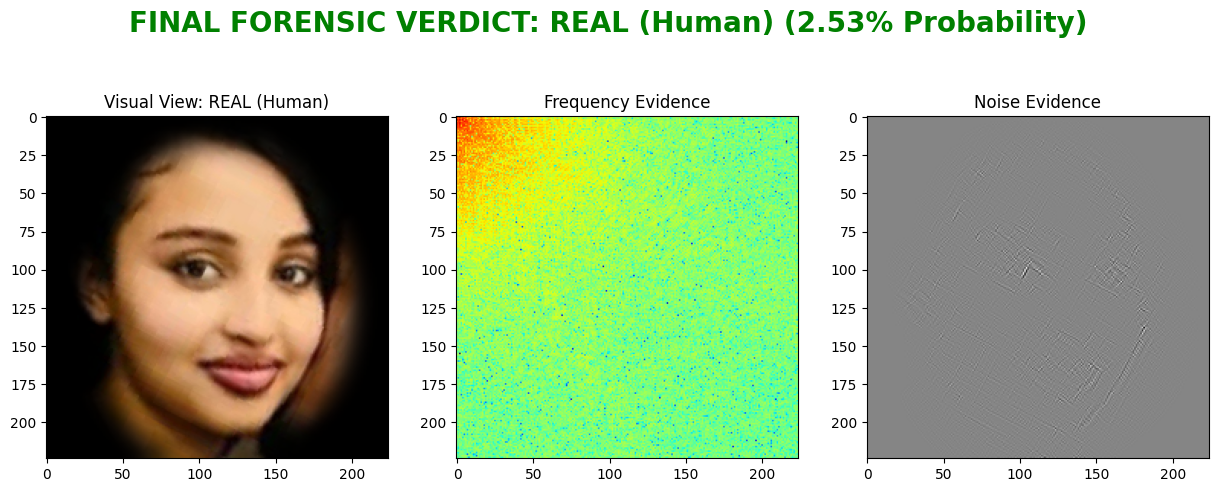

In [27]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN

# --- 1. SET YOUR TARGET IMAGE PATH ---
target_image_path = "/kaggle/input/datasets/esayasmelaku/test-image/5893129197146803328_121.jpg"

# --- 2. BUILD MODEL ARCHITECTURE (Exact match to your training) ---
def load_forensic_brain(weights_path):
    from tensorflow.keras import layers, models
    
    # Branch 1: RGB
    in_rgb = layers.Input(shape=(224, 224, 3), name="RGB_Input")
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=in_rgb)
    x_rgb = layers.GlobalAveragePooling2D()(base.output)
    
    # Branch 2: SRM (Noise)
    in_srm = layers.Input(shape=(224, 224, 3), name="SRM_Input")
    x_srm = layers.Conv2D(32, (3,3), activation='relu', padding='same')(in_srm)
    x_srm = layers.MaxPooling2D()(x_srm)
    x_srm = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x_srm)
    x_srm = layers.GlobalAveragePooling2D()(x_srm)
    
    # Branch 3: DCT (Frequency)
    in_dct = layers.Input(shape=(224, 224, 1), name="DCT_Input")
    x_dct = layers.Conv2D(32, (3,3), activation='relu', padding='same')(in_dct)
    x_dct = layers.MaxPooling2D()(x_dct)
    x_dct = layers.GlobalAveragePooling2D()(x_dct)
    
    # Fusion
    merged = layers.Concatenate()([x_rgb, x_srm, x_dct])
    x = layers.Dense(512, activation='relu')(merged)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid', name="Final_Decision")(x)
    
    model = models.Model(inputs=[in_rgb, in_srm, in_dct], outputs=out)
    
    # Load the best weights from your training
    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print(f"✅ Weights loaded from {weights_path}")
    else:
        print("⚠️ Warning: Weights file not found. Running with random initialization!")
        
    return model

# --- 3. THE FORENSIC PIPELINE FUNCTIONS ---
detector = MTCNN()

def process_single_image(img_path):
    # A. Load
    raw = cv2.imread(img_path)
    if raw is None: return None, None, None
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    
    # B. Robust Centering & Alignment
    results = detector.detect_faces(raw_rgb)
    if not results: return None, None, None
    
    landmarks = results[0]['keypoints']
    x, y, w, h = results[0]['box']
    center_x, center_y = x + w // 2, y + h // 2
    pad = max(raw_rgb.shape) // 2
    img_padded = cv2.copyMakeBorder(raw_rgb, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
    
    dX = (landmarks['right_eye'][0] + pad) - (landmarks['left_eye'][0] + pad)
    dY = (landmarks['right_eye'][1] + pad) - (landmarks['left_eye'][1] + pad)
    angle = np.degrees(np.arctan2(dY, dX))
    M = cv2.getRotationMatrix2D((center_x + pad, center_y + pad), angle, 1.0)
    rotated = cv2.warpAffine(img_padded, M, (img_padded.shape[1], img_padded.shape[0]))
    
    crop_size = int(max(w, h) * 1.3)
    cx, cy = center_x + pad, center_y + pad
    face = rotated[cy - crop_size//2 : cy + crop_size//2, cx - crop_size//2 : cx + crop_size//2]
    face = cv2.resize(face, (224, 224), interpolation=cv2.INTER_CUBIC)
    
    # C. Masking
    mask = np.zeros((224, 224), dtype=np.uint8)
    cv2.ellipse(mask, (112, 122), (85, 105), 0, 0, 360, 255, -1)
    mask_soft = cv2.GaussianBlur(mask, (51, 51), 0) / 255.0
    masked = (face * np.stack([mask_soft]*3, axis=-1)).astype(np.uint8)
    
    # D. Feature Extraction (DCT & SRM)
    # DCT
    y_chan = cv2.cvtColor(masked, cv2.COLOR_RGB2YUV)[:,:,0]
    dct = cv2.normalize(np.log(np.abs(cv2.dct(np.float32(y_chan)/255.0)) + 1e-12), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # SRM
    gray = cv2.cvtColor(masked, cv2.COLOR_RGB2GRAY)
    f1 = np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]])/4.0
    srm = cv2.normalize(cv2.filter2D(np.float32(gray), -1, f1), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    srm_3ch = cv2.merge([srm, srm, srm])
    
    return masked, dct, srm_3ch

# --- 4. EXECUTION ---
print("🔬 Initializing Forensic Engine...")
brain = load_forensic_brain('best_deepfake_model.keras')
masked_face, dct_map, srm_map = process_single_image(target_image_path)

if masked_face is not None:
    # Prepare inputs for the brain
    in_rgb = np.expand_dims(masked_face.astype('float32')/255.0, 0)
    in_srm = np.expand_dims(srm_map.astype('float32')/255.0, 0)
    in_dct = np.expand_dims(dct_map.astype('float32')/255.0, (0, -1))
    
    # Get Decision
    prob = brain.predict([in_rgb, in_srm, in_dct], verbose=0)[0][0]
    is_fake = prob > 0.5
    result = "FAKE (Deepfake)" if is_fake else "REAL (Human)"
    
    # Visualize
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(masked_face); plt.title(f"Visual View: {result}")
    plt.subplot(1, 3, 2); plt.imshow(dct_map, cmap='jet'); plt.title("Frequency Evidence")
    plt.subplot(1, 3, 3); plt.imshow(srm_map); plt.title("Noise Evidence")
    plt.suptitle(f"FINAL FORENSIC VERDICT: {result} ({prob*100:.2f}% Probability)", 
                 fontsize=20, fontweight='bold', color='red' if is_fake else 'green', y=1.05)
    plt.show()
else:
    print("❌ Analysis failed: Could not detect or center face.")